# Research AI Platform - arXiv Dataset EDA

This notebook showcases exploratory data analysis for the arXiv metadata used by the Research AI Intelligence Platform. It samples parquet chunks safely, builds broad research-category labels, exports tables/figures, and produces statistics suitable for the final project report.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'dataset' / 'data'
TABLE_DIR = PROJECT_ROOT / 'artifacts' / 'showcase' / 'tables'
FIG_DIR = PROJECT_ROOT / 'artifacts' / 'showcase' / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)

## 1. Load a Memory-Safe Sample

The source dataset is large, so the notebook reads from pre-split parquet chunks and samples a fixed number of rows per chunk. Increase `SAMPLE_SIZE` if your machine has enough memory.

In [2]:
SAMPLE_SIZE = 250_000
files = sorted((DATA_DIR / 'chunks_A').glob('*.parquet')) + sorted((DATA_DIR / 'chunks_B').glob('*.parquet'))
files[:3], len(files)

([WindowsPath('D:/main projects/research_ai_platform_v3.1_final/dataset/data/chunks_A/part_0.parquet'),
  WindowsPath('D:/main projects/research_ai_platform_v3.1_final/dataset/data/chunks_A/part_1.parquet'),
  WindowsPath('D:/main projects/research_ai_platform_v3.1_final/dataset/data/chunks_A/part_10.parquet')],
 48)

In [3]:
cols = ['id', 'title', 'abstract', 'categories', 'update_date', 'authors', 'doi', 'journal-ref']
per_file = max(1, SAMPLE_SIZE // max(1, len(files)))
frames = []
for path in files:
    chunk = pd.read_parquet(path, columns=cols)
    if len(chunk) > per_file:
        chunk = chunk.sample(per_file, random_state=42)
    frames.append(chunk)

df = pd.concat(frames, ignore_index=True)
if len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42)
df.shape

(249984, 8)

## 2. Schema, Missing Values, and Derived Features

In [4]:
def broad_category(categories):
    first = str(categories or '').strip().split()[0]
    if not first:
        return 'unknown'
    if first.startswith(('cs.', 'math.', 'stat.', 'eess.', 'econ.', 'q-bio.', 'q-fin.')):
        return first.split('.', 1)[0]
    if first.startswith('cond-mat.'):
        return 'cond-mat'
    if first.startswith('nlin.'):
        return 'nlin'
    if first.startswith('physics.'):
        return 'physics'
    return first

df['title'] = df['title'].fillna('').astype(str)
df['abstract'] = df['abstract'].fillna('').astype(str)
df['broad_category'] = df['categories'].map(broad_category)
df['year'] = pd.to_datetime(df['update_date'], errors='coerce').dt.year
df['title_chars'] = df['title'].str.len()
df['abstract_chars'] = df['abstract'].str.len()
df['token_count'] = (df['title'] + ' ' + df['abstract']).str.split().str.len()

schema = pd.DataFrame({'column': df.columns, 'dtype': [str(t) for t in df.dtypes]})
missing = df.isna().sum().rename('missing_count').reset_index().rename(columns={'index': 'column'})
schema.to_csv(TABLE_DIR / 'eda_schema.csv', index=False)
missing.to_csv(TABLE_DIR / 'eda_missing_values.csv', index=False)
display(schema)
display(missing)

,column,dtype
0,id,object
1,title,object
2,abstract,object
3,categories,object
4,update_date,object
5,authors,object
6,doi,object
7,journal-ref,object
8,broad_category,object
9,year,int32


,column,missing_count
0,id,0
1,title,0
2,abstract,0
3,categories,0
4,update_date,0
5,authors,0
6,doi,144369
7,journal-ref,177515
8,broad_category,0
9,year,0


## 3. Category Distribution

In [5]:
category_counts = df['broad_category'].value_counts().rename_axis('category').reset_index(name='count')
category_counts['percentage'] = category_counts['count'] / category_counts['count'].sum() * 100
category_counts.to_csv(TABLE_DIR / 'eda_category_distribution_full.csv', index=False)
category_counts.head(15)

,category,count,percentage
0,cs,67663,27.066932
1,math,51759,20.704925
2,cond-mat,26649,10.660282
3,physics,18824,7.530082
4,quant-ph,10451,4.180668
5,hep-ph,8973,3.589430
6,hep-th,6922,2.768977
7,eess,6629,2.651770
8,stat,5782,2.312948
9,gr-qc,5307,2.122936


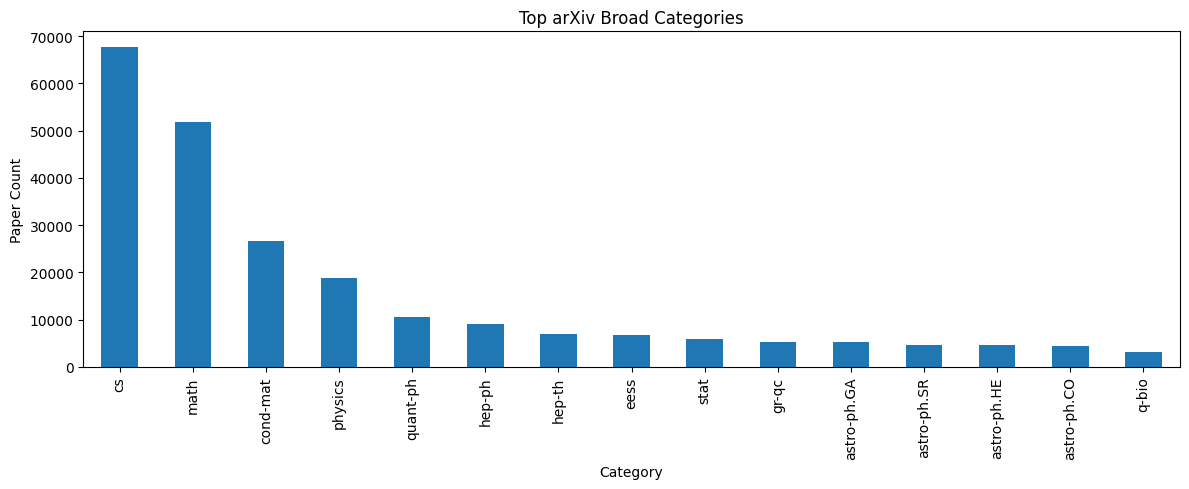

In [6]:
ax = category_counts.head(15).plot.bar(x='category', y='count', figsize=(12, 5), legend=False)
ax.set_title('Top arXiv Broad Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Paper Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_top_category_distribution.png', dpi=180)
plt.show()

## 4. Time Trend Analysis

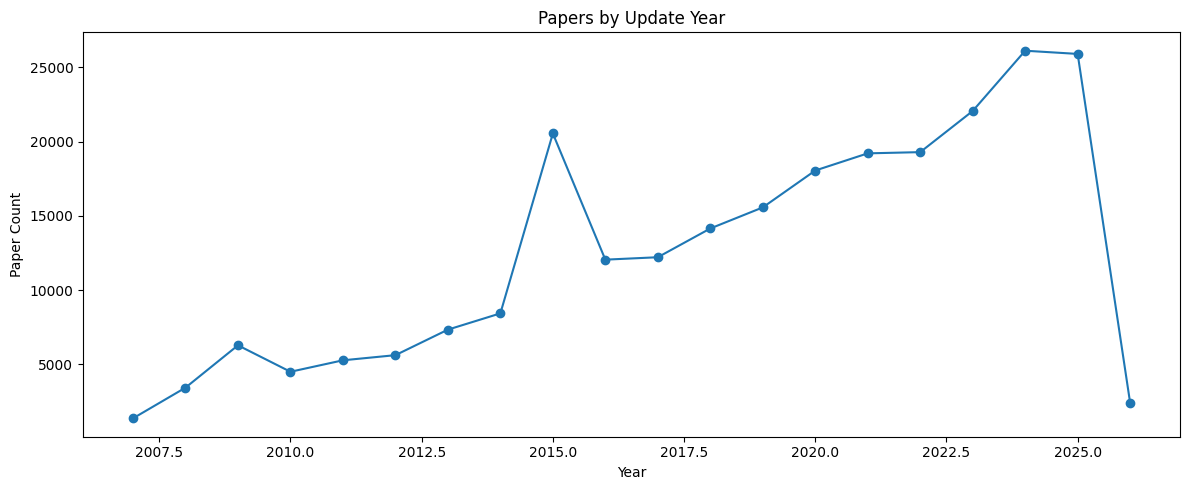

In [7]:
year_counts = df.dropna(subset=['year']).groupby('year').size().rename('count').reset_index()
year_counts.to_csv(TABLE_DIR / 'eda_year_distribution.csv', index=False)
ax = year_counts.plot.line(x='year', y='count', marker='o', figsize=(12, 5), legend=False)
ax.set_title('Papers by Update Year')
ax.set_xlabel('Year')
ax.set_ylabel('Paper Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_year_trend.png', dpi=180)
plt.show()

## 5. Text Length Analysis

,count,mean,std,min,25%,50%,75%,max
title_chars,249984.0,76.570457,27.645112,5.0,57.0,75.0,93.0,280.0
abstract_chars,249984.0,1020.934932,427.286594,6.0,695.0,1004.0,1329.0,4031.0
token_count,249984.0,158.746672,63.241787,8.0,112.0,156.0,203.0,546.0


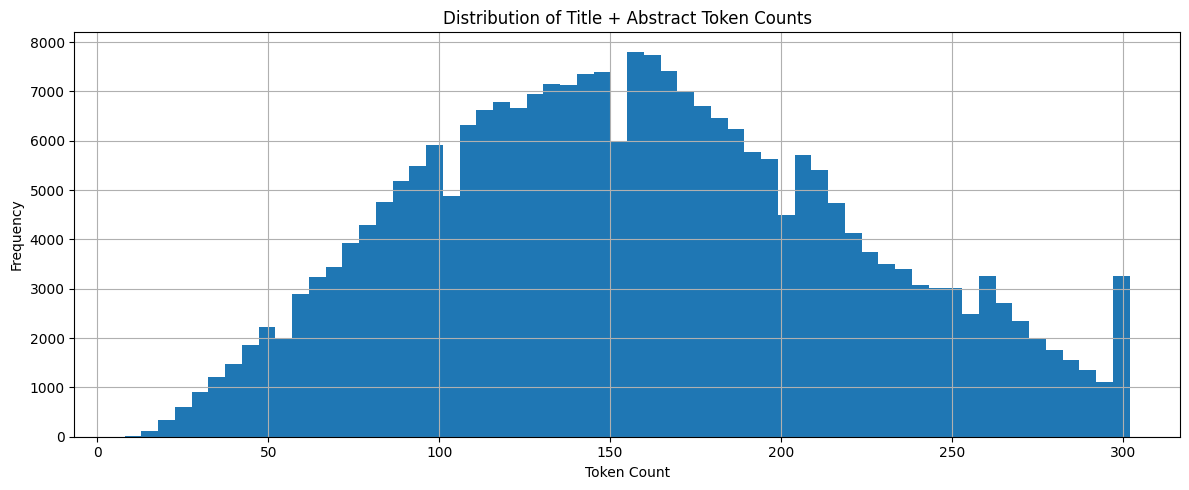

In [8]:
length_summary = df[['title_chars', 'abstract_chars', 'token_count']].describe().T
length_summary.to_csv(TABLE_DIR / 'eda_text_length_summary.csv')
display(length_summary)

ax = df['token_count'].clip(upper=df['token_count'].quantile(0.99)).hist(bins=60, figsize=(12, 5))
ax.set_title('Distribution of Title + Abstract Token Counts')
ax.set_xlabel('Token Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_token_hist_full.png', dpi=180)
plt.show()

## 6. EDA Summary for Report

In [9]:
summary = {
    'sample_rows': int(len(df)),
    'unique_papers': int(df['id'].nunique()),
    'broad_categories': int(df['broad_category'].nunique()),
    'top_category': category_counts.iloc[0].to_dict(),
    'year_min': int(df['year'].min()) if df['year'].notna().any() else None,
    'year_max': int(df['year'].max()) if df['year'].notna().any() else None,
    'median_token_count': float(df['token_count'].median()),
}
(TABLE_DIR / 'eda_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary

{'sample_rows': 249984,
 'unique_papers': 249984,
 'broad_categories': 26,
 'top_category': {'category': 'cs',
  'count': 67663,
  'percentage': 27.066932283666155},
 'year_min': 2007,
 'year_max': 2026,
 'median_token_count': 156.0}